In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import tabix
import gzip
import pysam
# import vcf

In [105]:

def plot_isoform_annotations(annotation_exons, gene, colores=None, start=None, end=None, 
                             figsize=None, lwidth=5, iso_order=None, axes=None, xlim=None, var_pos=None):

    gene_exons = annotation_exons.loc[annotation_exons.gene_id == gene]

    if iso_order is None:
        isoforms = sorted(gene_exons.transcript_id.unique())
    else:
        isoforms = iso_order

    isoform_dict = {}
    for i, iso in enumerate(isoforms):
        isoform_name = f'isoform_{str(i+1)}'
        df = gene_exons.loc[gene_exons.transcript_id == iso].copy()
        df['transcript_id'] =  f'{gene}.{isoform_name}'
        isoform_dict.update({isoform_name:{'df':df}})

    try:
        chrom = list(annotation_exons.chrom)[0]
    except:
        chrom = list(annotation_exons['chrom'])[0]
    if start is None:
        start = str(np.min([int(list(gene_exons.start)[0]), int(list(gene_exons.start)[0])]) - 1000)
    if end is None:
        end = str(np.max([int(list(gene_exons.end)[-1]), int(list(gene_exons.end)[-1])]) + 1000)

    coords = [f'{chrom}:{start}', f'{chrom}:{end}']

    # print(isoform_dict)

    plot_gene_isoforms(isoform_dict, coords, color_list = colores, figsize=figsize, lwidth=lwidth, axes=axes, xlim=xlim, var_pos = var_pos)


def plot_gene_isoforms(isoforms_dict, coordinates, color_list = None, axes=None, figsize=None, lwidth=5, xlim=None, var_pos=None):


    if xlim is None:
        xlim1 = int(coordinates[0].split(':')[1])
        xlim2 = int(coordinates[-1].split(':')[1])
#         print(xlim)
    else:
        xlim1 = xlim[0]
        xlim2 = xlim[1]

    if var_pos > xlim2:
        xlim2 = var_pos + 1000
    if var_pos < xlim1:
        xlim1 = var_pos - 1000

    
    

    if color_list is None:
        color_list = sns.color_palette("tab10")

    K = len(isoforms_dict)

    if figsize is None:
        figsize=(20, 3)

    if axes is None:
        fig, axes = plt.subplots(K, 1, figsize=figsize)

    for i in range(K):
        
            
        isoform_df = isoforms_dict[f'isoform_{str(i+1)}']['df']
        # print(isoform_df)
        ax = axes[i]
        color = color_list[i]
        plot_isoform(isoform_df, ax, color, xlim1, xlim2, lwidth=lwidth)
        if (var_pos is not None):
            axes[i].plot([var_pos, var_pos], [0, 1], 'r--')


def plot_isoform(isoform_df, ax, color, xlim1, xlim2, lwidth):
    # print(isoform_df)
    is_first = True
    for idx, row in isoform_df.iterrows():
        start = int(row.start)
        end = int(row.end)
        if is_first:
            first = end
            is_first = False
    
        ax.fill_between([start, end], [0, 0], [1, 1], color = color, zorder=2)
    
    ax.plot([first, start], [0.5, 0.5], c=color, linewidth=lwidth)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[['bottom', 'top', 'right', 'left']].set_visible(False)
    ax.set_xlim([xlim1, xlim2])

    # print(xlim1, xlim2)


In [106]:
import pysam
import gzip
import pandas as pd

def run_tabix(
    tabix_file,
    chrom,
    start,
    end,
    file_type="other"
):
    # Open tabix-indexed file
    tbx = pysam.TabixFile(tabix_file)

    # Fetch rows in region
    rows = [
        line.rstrip("\n").split("\t")
        for line in tbx.fetch(chrom, start, end)
    ]

    if not rows:
        return pd.DataFrame()

    # Try to get column names from header
    header = None
    if tbx.header:
        # Take the last header line (common tabix convention)
        header = tbx.header[-1].lstrip("#").split("\t")
    else:
        # Fallback: read first line of gzipped file
        with gzip.open(tabix_file, "rt") as fh:
            header = fh.readline().rstrip("\n").split("\t")

    df = pd.DataFrame(rows, columns=header)

    # Post-processing by file type
    if file_type == "leafcutter":
        df["gid"] = df["pid"].str.split(":").str[3]
    elif file_type == "expression":
        df["gid"] = df["pid"].str.split(".").str[0]

    return df

def fetch_variant(vcf_in, var_id):
    chrom, pos, ref, alt, tag = var_id.split('_') #"chr5_52897294_A_G_b38"
    pos = int(pos)
    for record in vcf_in.fetch(chrom, pos-1, pos+1):
        if (record.chrom == chrom) and (pos == record.pos) and (ref == record.ref) and (alt in record.alts):
            return record
    return None

def fetch_genotypes(vcf_in, var_id, samples):
    record = fetch_variant(vcf_in, var_id)
    if record is None:
        return None

    genotypes_list = []
    record_dict = dict(record.samples.items())
    for sample in samples:
        if sample in record_dict.keys():
            sample_gt = np.sum(record_dict[sample]['GT'])
        else:
            sample_gt = np.nan
        genotypes_list.append(sample_gt)

    return genotypes_list

def fetch_genotype_class(record, samples):
    # record = fetch_variant(vcf_in, var_id)
    if record is None:
        return None

    genotypes_class = {'hom_refs':[],
                       'hets':[],
                       'hom_alts':[]
                      }
    record_dict = dict(record.samples.items())
    for sample in samples:
        if sample in record_dict.keys():
            sample_gt = np.sum(record_dict[sample]['GT'])
        else:
            sample_gt = np.nan

        if sample_gt == 0:
            genotypes_class['hom_refs'].append(sample)
        elif sample_gt == 1:
            genotypes_class['hets'].append(sample)
        elif sample_gt == 2:
            genotypes_class['hom_alts'].append(sample)
        # genotypes_list.append(sample_gt)

    return genotypes_class


def make_boxplot_df(qqnorm_data, phenotype, record, phenotype_class='',  color='black'):
    qq_samples = qqnorm_data.columns[6:]
    genotypes_class = fetch_genotype_class(record, qq_samples)
    hom_refs = genotypes_class['hom_refs']#[str(x.sample) for x in record.get_hom_refs() if str(x.sample) in qq_samples]
    hets = genotypes_class['hets']#[str(x.sample) for x in record.get_hets() if str(x.sample) in qq_samples]
    hom_alts = genotypes_class['hom_alts']#[str(x.sample) for x in record.get_hom_alts() if str(x.sample) in qq_samples]
    
    samples = hom_refs + hets + hom_alts
    
    ref = record.ref
    alt = record.alts[0]
    
    genotype = [str(ref) + ',' + str(ref)]*len(hom_refs)
    genotype += [str(ref) + ',' + str(alt)]*len(hets)
    genotype += [str(alt) + ',' + str(alt)]*len(hom_alts)
    
    df = pd.DataFrame()
    df['genotype'] = genotype
    df['qqnorm'] = list(qqnorm_data.loc[phenotype, samples].astype(float))
    df.index = hom_refs + hets + hom_alts

    # return df
    
    
    
    
    # plt.figure(figsize=(2.5, 2.5))
    fig, ax = plt.subplots(figsize=(2.5, 2.5), dpi=300)
    
    sns.boxplot(x = 'genotype', y = 'qqnorm', data = df, width=.8, showfliers=False,
                     linewidth=2,  boxprops=dict(facecolor='white', edgecolor=color),
           whiskerprops = dict(color=color),
           capprops = dict(color=color),
           medianprops = dict(linewidth=2, color='black'), ax=ax)#, palette=colorbrewer)

    

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax.tick_params(size=4, width=2, labelsize=14)
    # sns.despine(offset=5, trim=True)
    sns.stripplot(x = 'genotype', y = 'qqnorm', data = df, alpha=0.9, edgecolor=color, facecolor='none', linewidth=1, ax=ax, rasterized=True)
    # ax.set_yticks([-1, 0, 1])
    # plt.title(phenotype_class + ': ' +phenotype, size=14)
    return ax

In [19]:
gwas = run_tabix('../code/resources/gwas/StatsForColoc/Bipolar_disorder.standardized.txt.tabix.gz', 
          'chr17', 44176940-1000000, 44177608+1000000)

gwas['snp_pos'] = gwas.chrom + ':' + gwas.start

gwas_pval = run_tabix('/project2/mstephens/cfbuenabadn/gtex-stm/code/gwas/hg38_summary_stats/bipolar_disorder.bed.gz', 
          'chr17', 44176940-1000000, 44177608+1000000)

gwas_pval['snp_pos'] = gwas_pval['chrom'] + ':' + gwas_pval.start

nom_bch = run_tabix('../code/results/coloc/qtls/Brain-CerebellarHemisphere/leafcutter.NominalPass/chr17.txt.tabix.gz',
               'chr17', 44176940-1000000, 44177608+1000000)

nom_bch['snp_pos'] = nom_bch.var_chr + ':' + nom_bch.var_from


nom_bch_e = run_tabix('../code/results/coloc/qtls/Brain-CerebellarHemisphere/expression.NominalPass/chr17.txt.tabix.gz',
               'chr17', 44176940-1000000, 44177608+1000000)

nom_bch_e['snp_pos'] = nom_bch_e.var_chr + ':' + nom_bch_e.var_from

nom_bch['gwas_trait'] = nom_bch['phe_id'].apply(lambda x: x.split(':')[-1])
nom_bch_e['gwas_trait'] = nom_bch_e['phe_id'].apply(lambda x: x.split(':')[-1])

nom_bch = nom_bch.loc[(nom_bch.gwas_trait == 'chr17_44114525_N_N_bipolar_disorder') & (nom_bch['phe_id'] == 'chr17:44176940:44177608:clu_28859_+:UP:chr17_44114525_N_N_bipolar_disorder')]
nom_bch_e = nom_bch_e.loc[(nom_bch_e.gwas_trait == 'chr17_44114525_N_N_bipolar_disorder') & (nom_bch_e['phe_id'].apply(lambda x: ('ENSG00000161664' in x) and ('chr17_44114525_N_N_bipolar_disorder' in x)))]


In [37]:
hyprcoloc = pd.read_csv('../code/results/coloc/hyprcoloc_results/tables/annotated_results.tsv.gz', sep='\t')

# Here we observe the candidate SNP

In [45]:
hyprcoloc.loc[(hyprcoloc.expr_colocs) & (hyprcoloc.UP_colocs) & (hyprcoloc.gwas_colocs) & (hyprcoloc.gwas_loci == 'chr17_44114525_N_N_bipolar_disorder')]#.loc[80030]#.traits

,iteration,traits,posterior_prob,regional_prob,candidate_snp,posterior_explained_by_snp,dropped_trait,gwas_trait,gwas_colocs,UP_colocs,expr_colocs,lfc_colocs,lfc_other_colocs,gwas_loci,tissue
45416,1,"chr17_44114525_N_N_bipolar_disorder, :, Brain-...",0.2839,0.5215,chr17_44176913_A_G_b38,0.4197,NaN,bipolar_disorder,True,True,True,True,False,chr17_44114525_N_N_bipolar_disorder,Brain-CerebellarHemisphere
45418,1,"chr17_44114525_N_N_bipolar_disorder, :, Brain-...",0.5826,0.8152,chr17_44176913_A_G_b38,0.4481,NaN,bipolar_disorder,True,True,True,True,False,chr17_44114525_N_N_bipolar_disorder,Brain-Cerebellum
45444,1,"chr17_44114525_N_N_bipolar_disorder, :, Heart-...",0.4078,0.6548,chr17_44176913_A_G_b38,0.8058,NaN,bipolar_disorder,True,True,True,True,False,chr17_44114525_N_N_bipolar_disorder,Heart-AtrialAppendage
45445,1,"chr17_44114525_N_N_bipolar_disorder, :, Heart-...",0.5906,0.9245,chr17_44176643_C_G_b38,0.1962,NaN,bipolar_disorder,True,True,True,True,False,chr17_44114525_N_N_bipolar_disorder,Heart-LeftVentricle
45450,1,"chr17_44114525_N_N_bipolar_disorder, :, Muscle...",0.6988,1.0000,chr17_44176643_C_G_b38,0.2511,NaN,bipolar_disorder,True,True,True,True,False,chr17_44114525_N_N_bipolar_disorder,Muscle-Skeletal


### Observe colocalization of trait and UP splicing

In [46]:
hyprcoloc.loc[(hyprcoloc.expr_colocs) & (hyprcoloc.UP_colocs) & (hyprcoloc.gwas_colocs) & (hyprcoloc.gwas_loci == 'chr17_44114525_N_N_bipolar_disorder')].loc[45416].traits

'chr17_44114525_N_N_bipolar_disorder, :, Brain-CerebellarHemisphere.leafcutter_N_N_chr17:44176940:44177608:clu_28859_+:UP:ENSG00000161664.6, Brain-CerebellarHemisphere.leafcutter_N_N_chr17:44177230:44177608:clu_28859_+:PR:ENSG00000161664.6, Brain-CerebellarHemisphere.expression_N_N_ENSG00000108840, Brain-CerebellarHemisphere.expression_N_N_ENSG00000161664'

### Notes:

Unproductive splicig in ASB16: Brain-CerebellarHemisphere.leafcutter_N_N_chr17:44176940:44177608:clu_28859_+:UP:ENSG00000161664.6

And its expression are both colocalized in Brain-CerebellarHemisphere

Candidate variant is chr17_44176913_A_G_b38

In [47]:
snps = pd.Index(nom_bch.snp_pos).intersection(pd.Index(gwas_pval.snp_pos)).intersection(pd.Index(gwas.snp_pos)).intersection(pd.Index(nom_bch_e.snp_pos))

In [56]:
gwas_pval = gwas_pval.groupby('snp_pos').first()

nom_bch = nom_bch.groupby('snp_pos').first()
nom_bch_e = nom_bch_e.groupby('snp_pos').first()

In [50]:
LD = pd.read_csv('../code/results/coloc/LD/chr17_44114525_N_N_bipolar_disorder.tsv.gz', sep='\t')
LD.columns = [':'.join(x.split('_')[:2]) for x in LD.columns]
LD.index = LD.columns
LD = LD.astype(float)**2

snps_shared = snps.intersection(LD.columns)



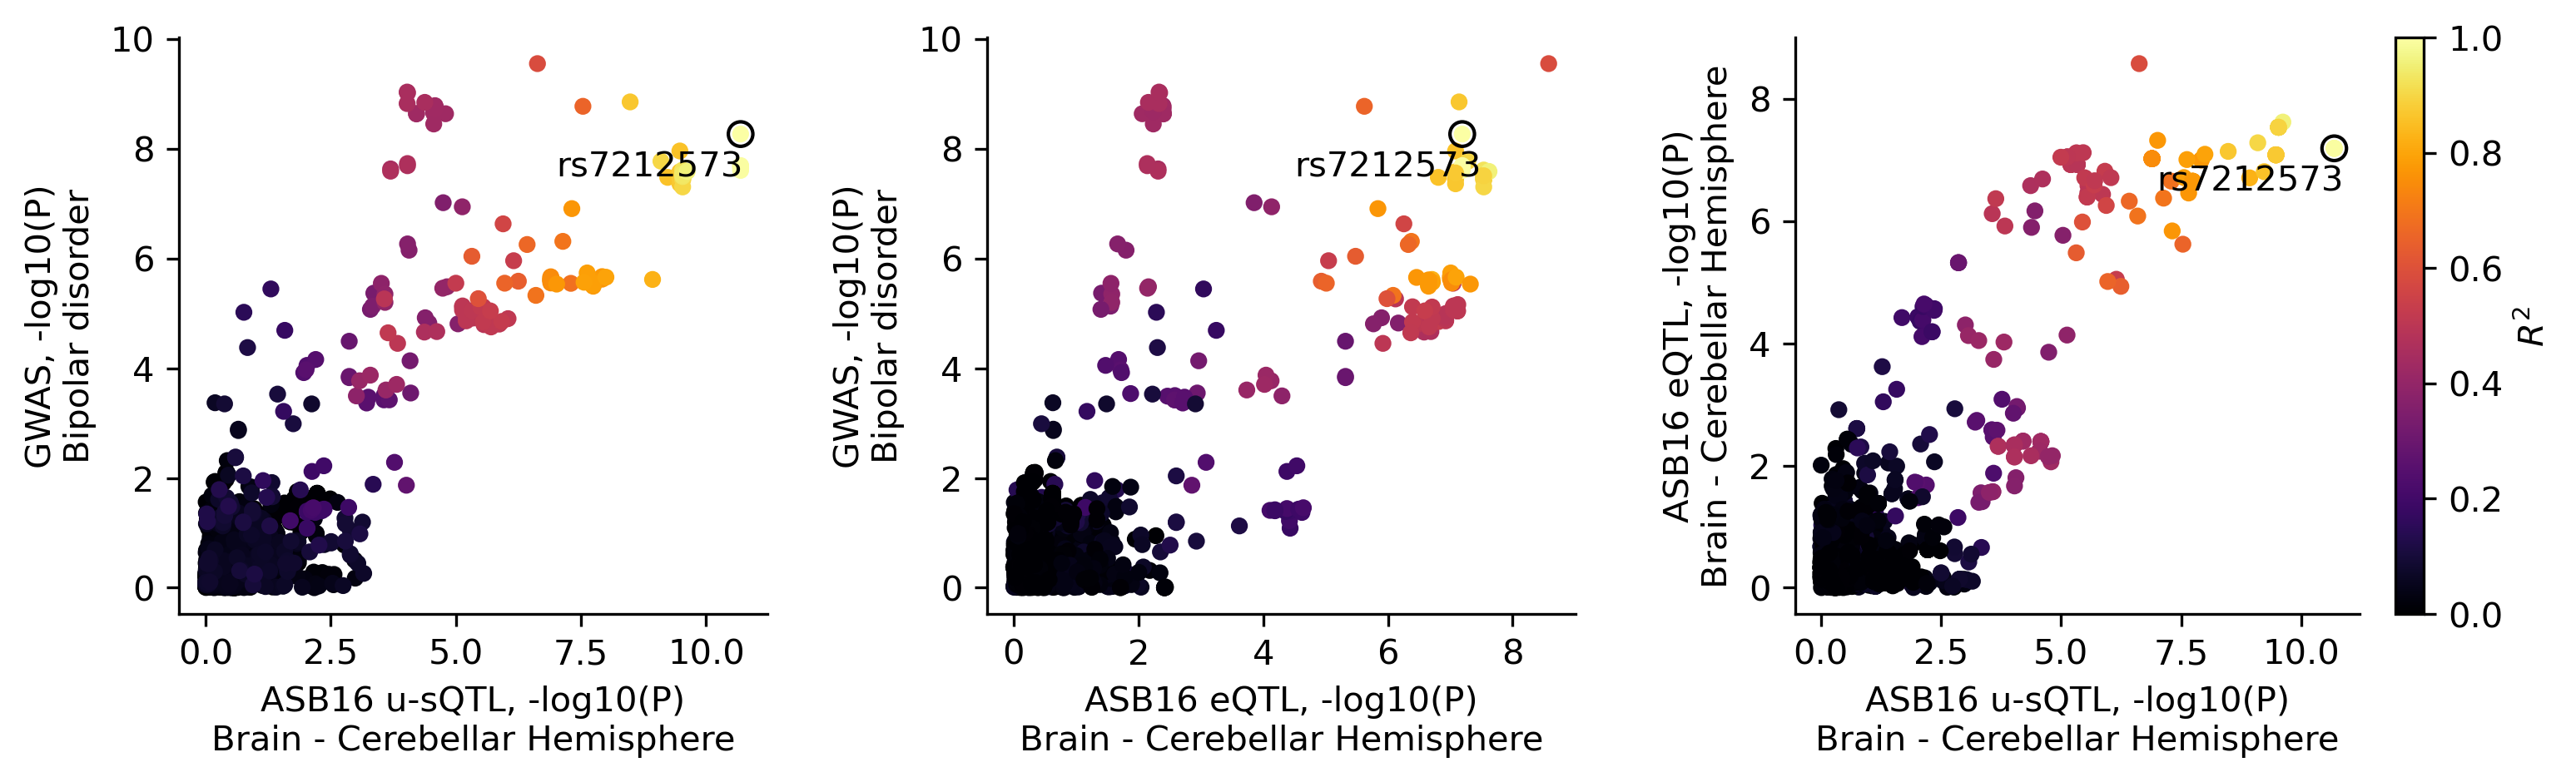

In [57]:
fig, ax = plt.subplots(ncols= 3, figsize=(12, 3), width_ratios=[1, 1, 1.2], dpi=300)
y = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float)))
x = -np.log10(np.array(nom_bch.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr17:44176913', snps_shared]

scatter_df = pd.DataFrame()
scatter_df['r2'] = r2
scatter_df['sQTL'] = x
scatter_df['GWAS'] = y
scatter_df = scatter_df.sort_values('r2')

c=ax[0].scatter(scatter_df.sQTL, scatter_df.GWAS, c=scatter_df.r2, s=15, cmap='inferno', vmin=0, rasterized=True)
# plt.colorbar(c)
ax[0].set_xlabel('ASB16 u-sQTL, -log10(P)\nBrain - Cerebellar Hemisphere')
ax[0].set_ylabel('GWAS, -log10(P)\nBipolar disorder')

y_r = -np.log10(np.array(gwas_pval.loc[['chr17:44176913']].P.astype(float)))
x_r = -np.log10(np.array(nom_bch.loc[['chr17:44176913']].nom_pval.astype(float)))
ax[0].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[0].text(7, 7.5, 'rs7212573')



y = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float)))
x = -np.log10(np.array(nom_bch_e.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr17:44176913', snps_shared]
c=ax[1].scatter(x, y, c=r2, s=15, cmap='inferno', vmin=0, rasterized=True)
# plt.colorbar(c)
ax[1].set_xlabel('ASB16 eQTL, -log10(P)\nBrain - Cerebellar Hemisphere')
ax[1].set_ylabel('GWAS, -log10(P)\nBipolar disorder')

y_r = -np.log10(np.array(gwas_pval.loc[['chr17:44176913']].P.astype(float)))
x_r = -np.log10(np.array(nom_bch_e.loc[['chr17:44176913']].nom_pval.astype(float)))
ax[1].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[1].text(4.5, 7.5, 'rs7212573')



x = -np.log10(np.array(nom_bch.loc[snps_shared].nom_pval.astype(float)))
y = -np.log10(np.array(nom_bch_e.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr17:44176913', snps_shared]
c=ax[2].scatter(x, y, c=r2, s=15, cmap='inferno', vmin=0, rasterized=True)
plt.colorbar(c, label=r'$R^2$')
ax[2].set_xlabel('ASB16 u-sQTL, -log10(P)\nBrain - Cerebellar Hemisphere')
ax[2].set_ylabel('ASB16 eQTL, -log10(P)\nBrain - Cerebellar Hemisphere')

x_r = -np.log10(np.array(nom_bch.loc[['chr17:44176913']].nom_pval.astype(float)))
y_r = -np.log10(np.array(nom_bch_e.loc[['chr17:44176913']].nom_pval.astype(float)))
ax[2].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[2].text(7, 6.5, 'rs7212573')

ax[0].spines[['top', 'right']].set_visible(False)
ax[1].spines[['top', 'right']].set_visible(False)
ax[2].spines[['top', 'right']].set_visible(False)

fig.subplots_adjust(wspace=0.35, hspace=5)

# plt.savefig('../code/plots/fig4_coloc_example.png', dpi=300, bbox_inches='tight')
# plt.savefig('../code/plots/fig4_coloc_example.pdf', dpi=300, bbox_inches='tight')
# plt.savefig('../code/plots/fig4_coloc_example.svg', dpi=300, bbox_inches='tight')

In [128]:
qqnorm_bch = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Brain-CerebellarHemisphere/chr17.leafcutter.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr17', 44176940-30000, 44177608+30000, file_type='leafcutter')

qqnorm_bch_e = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Brain-CerebellarHemisphere/chr17.expression.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr17', 44176940-30000, 44177608+30000, file_type='expression')

qqnorm_bch.index = qqnorm_bch.pid
qqnorm_bch_e.index = qqnorm_bch_e.pid

In [129]:
# chr17:44176940:44177608:clu_29318_+:UP:chr17_44114525_N_N_bipolar_disorder

Text(0.5, 1.0, 'ASB16 unproductive splicing\nBrain - Cerebellar Hemisphere')

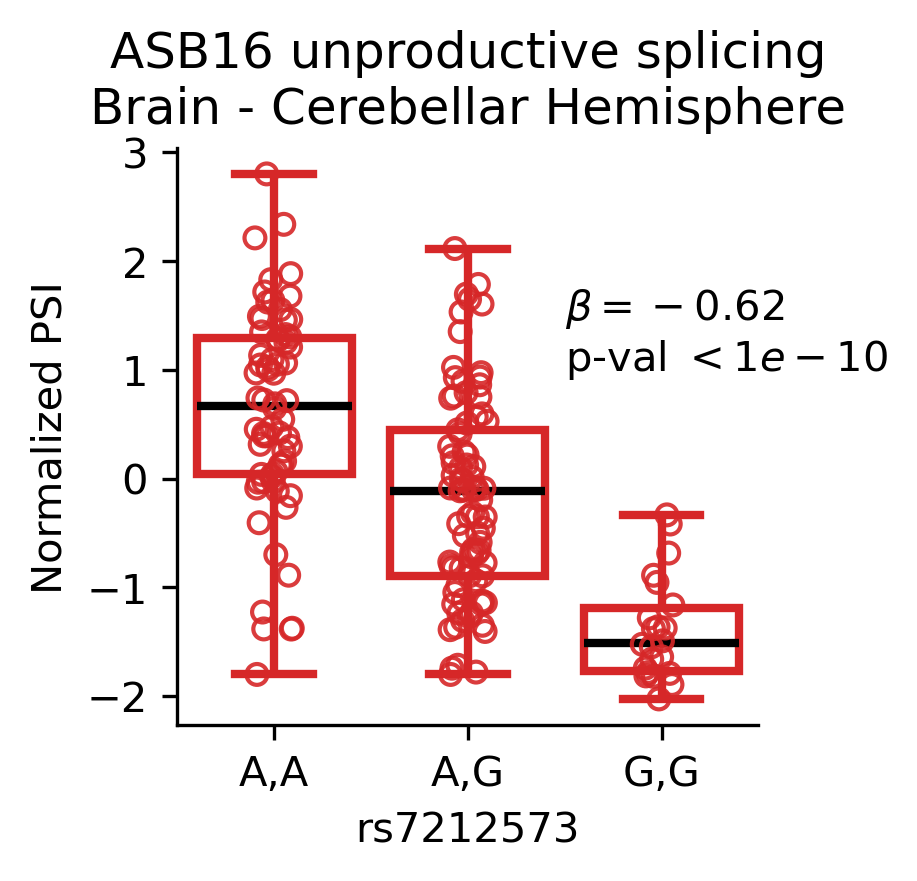

In [130]:
vcf_in = pysam.VariantFile('/project2/yangili1/cfbuenabadn/torino_paper/code/resources/GTEx/genotype/GTEx_Analysis_2017-06-05_v8_WGS_VCF_files_GTEx_Analysis_2017-06-05_v8_WholeGenomeSeq_838Indiv_Analysis_Freeze.SHAPEIT2_phased.vcf.gz')  # automatically detects format

record = fetch_variant(vcf_in, 'chr17_44176913_A_G_b38')


ax = make_boxplot_df(qqnorm_bch, 'chr17:44176940:44177608:clu_28859_+:UP:chr17_44114525_N_N_bipolar_disorder', record, color = 'tab:red')

ax.text(1.5, 1, r'$\beta = -0.62$' + '\np-val $< 1e-10$')


ax.set_xlabel('rs7212573')
ax.set_ylabel('Normalized PSI')
ax.set_title('ASB16 unproductive splicing\nBrain - Cerebellar Hemisphere')
# ax.set_xlabel('rs7212573')
# ax.set_ylabel('normalized splicing\nBrain Cerebellum')


In [131]:
nom_bch.loc['chr17:44176913'].nom_pval

'2.05388e-11'

In [132]:
nom_bch.loc['chr17:44176913'].slope

'-0.622274'

In [133]:
nom_bch_e.loc['chr17:44176913'].nom_pval

'6.44861e-08'

In [134]:
nom_bch_e.loc['chr17:44176913'].slope

'0.246418'

Text(1.5, -2.8, '$\\beta = 0.25$\np-val $< 1e-7$')

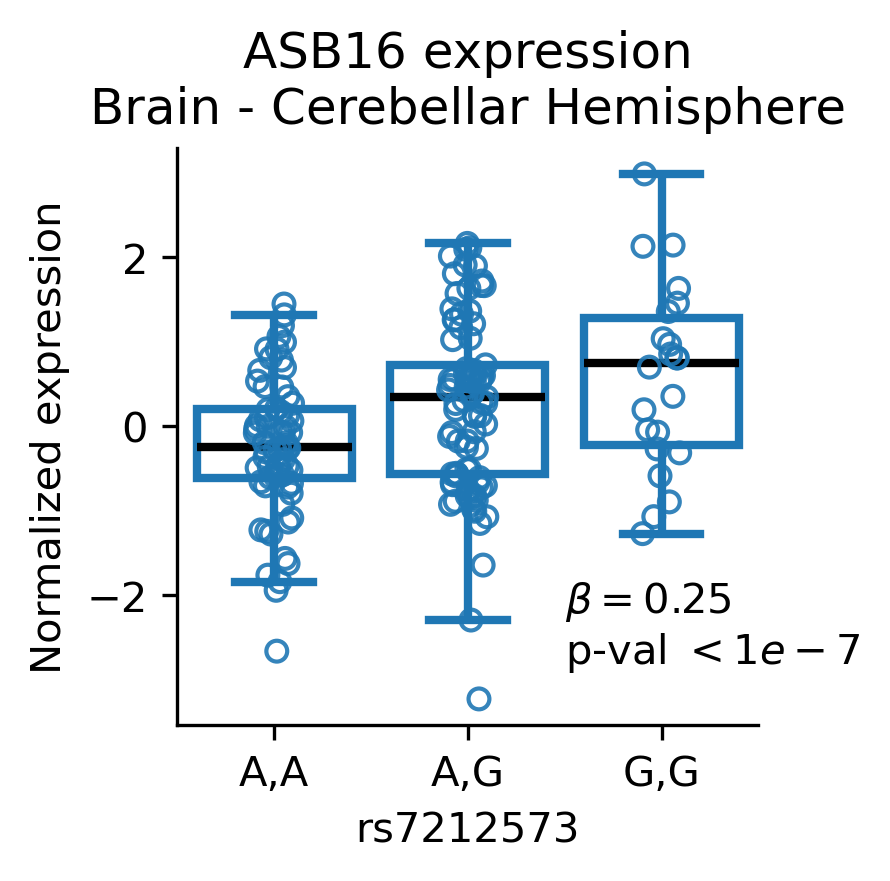

In [135]:
ax = make_boxplot_df(qqnorm_bch_e, 'ENSG00000161664.7:chr17_44114525_N_N_bipolar_disorder', record, color = 'tab:blue')

ax.set_xlabel('rs7212573')
ax.set_ylabel('Normalized expression')
ax.set_title('ASB16 expression\nBrain - Cerebellar Hemisphere')

ax.text(1.5, -2.8, r'$\beta = 0.25$' + '\np-val $< 1e-7$')


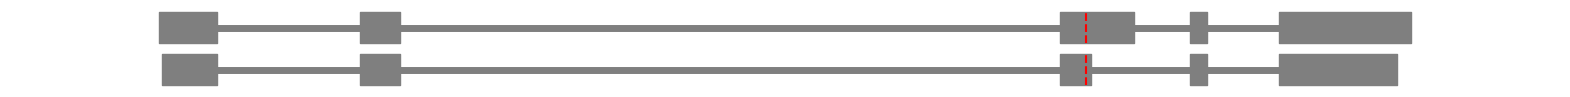

In [96]:
annot = run_tabix('/project2/mstephens/cfbuenabadn/gtex-stm/code/Annotations/gencode.v44.primary_assembly.exons.bed.gz', 
          'chr17', 44176940-30000, 44177608+30000)

plot_isoform_annotations(annot.loc[annot.transcript_id.isin(['ENST00000293414', 'ENST00000589618'])], 'ENSG00000161664', 
                         colores=['tab:gray']*2, start=None, end=None, figsize=(20, 1), lwidth=5, iso_order=None, var_pos = 44176913)

plt.savefig('../code/plots/fig4_ASB16_with_snp.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4_ASB16_with_snp.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4_ASB16_with_snp.svg', dpi=300, bbox_inches='tight')

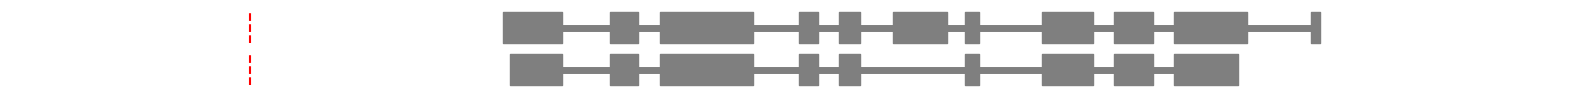

In [117]:
annot = run_tabix('/project2/mstephens/cfbuenabadn/gtex-stm/code/Annotations/gencode.v44.primary_assembly.exons.bed.gz', 
          'chr11', 614037-30000, 614475+30000)

plot_isoform_annotations(annot.loc[annot.transcript_id.isin(['ENST00000525445','ENST00000469048',])], 
                         'ENSG00000185507', 
                         colores=['tab:gray', 'tab:gray'],  figsize=(20, 1), lwidth=5, 
                         iso_order=['ENST00000525445','ENST00000469048'], var_pos = 611503)


plt.savefig('../code/plots/fig4_IRF7_with_snp.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4_IRF7_with_snp.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4_IRF7_with_snp.svg', dpi=300, bbox_inches='tight')

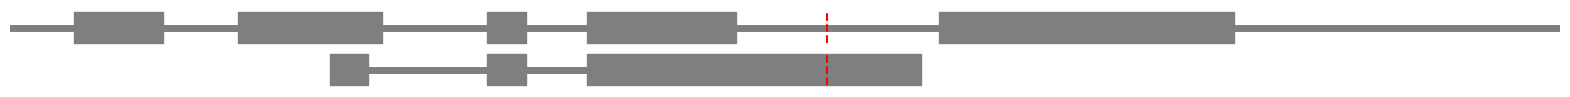

In [118]:
annot = run_tabix('/project2/mstephens/cfbuenabadn/gtex-stm/code/Annotations/gencode.v44.primary_assembly.exons.bed.gz', 
          'chr11', 802376-30000, 802542+30000)

plot_isoform_annotations(annot.loc[annot.transcript_id.isin(['ENST00000528122', 'ENST00000411829'])], 'ENSG00000177595', 
                         colores=['tab:gray']*3, start=802376-500, end=802542+1500, figsize=(20, 1), lwidth=5, iso_order=None, var_pos = 803017)

plt.savefig('../code/plots/fig4_PIDD1_with_snp.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4_PIDD1_with_snp.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4_PIDD1_with_snp.svg', dpi=300, bbox_inches='tight')

In [119]:

hyprcoloc.loc[(hyprcoloc.expr_colocs) & (hyprcoloc.UP_colocs) & (hyprcoloc.gwas_colocs) & (hyprcoloc.gwas_loci == 'chr11_803017_N_N_GCST004988')]#.loc[80030]#.traits

,iteration,traits,posterior_prob,regional_prob,candidate_snp,posterior_explained_by_snp,dropped_trait,gwas_trait,gwas_colocs,UP_colocs,expr_colocs,lfc_colocs,lfc_other_colocs,gwas_loci,tissue
12306,7,"chr11_803017_N_N_GCST004988, Esophagus-Gastroe...",0.3658,0.7252,chr11_803017_A_G_b38,0.6434,NaN,GCST004988,True,True,True,True,False,chr11_803017_N_N_GCST004988,Esophagus-GastroesophagealJunction
12408,5,"chr11_803017_N_N_GCST004988, Pituitary.leafcut...",0.4837,0.9450,chr11_803017_A_G_b38,0.5776,NaN,GCST004988,True,True,True,True,False,chr11_803017_N_N_GCST004988,Pituitary


In [161]:
gwas = run_tabix('../code/resources/gwas/StatsForColoc/Breast_cancer.standardized.txt.tabix.gz', 
          'chr11', 0, 803017+1000000)

gwas['snp_pos'] = gwas.chrom + ':' + gwas.start

gwas_pval = run_tabix('/project2/yangili1/bjf79/ChromatinSplicingQTLs/code/gwas_summary_stats/sorted_index_summarystat_hg38beds/GCST004988.bed.gz', 
          'chr11', 0, 803017+1000000)

gwas_pval['snp_pos'] = gwas_pval['Chr'] + ':' + gwas_pval.start

nom = run_tabix('../code/results/coloc/qtls/Pituitary/leafcutter.NominalPass/chr11.txt.tabix.gz',
               'chr11', 0, 803017+1000000)

nom['snp_pos'] = nom.var_chr + ':' + nom.var_from


nom_e = run_tabix('../code/results/coloc/qtls/Pituitary/expression.NominalPass/chr11.txt.tabix.gz',
               'chr11', 0, 803017+1000000)

nom_e['snp_pos'] = nom_e.var_chr + ':' + nom_e.var_from

nom['gwas_trait'] = nom['phe_id'].apply(lambda x: x.split(':')[-1])
nom_e['gwas_trait'] = nom_e['phe_id'].apply(lambda x: x.split(':')[-1])





nom_bm = run_tabix('../code/results/coloc/qtls/Breast-MammaryTissue/leafcutter.NominalPass/chr11.txt.tabix.gz',
               'chr11', 0, 803017+1000000)

nom_bm['snp_pos'] = nom_bm.var_chr + ':' + nom_bm.var_from


nom_bm_e = run_tabix('../code/results/coloc/qtls/Breast-MammaryTissue/expression.NominalPass/chr11.txt.tabix.gz',
               'chr11', 0, 803017+1000000)

nom_bm_e['snp_pos'] = nom_bm_e.var_chr + ':' + nom_bm_e.var_from

nom_bm['gwas_trait'] = nom_bm['phe_id'].apply(lambda x: x.split(':')[-1])
nom_bm_e['gwas_trait'] = nom_bm_e['phe_id'].apply(lambda x: x.split(':')[-1])



In [ ]:
nom_bm = run_tabix('../code/results/coloc/qtls/Breast-MammaryTissue/leafcutter.NominalPass/chr11.txt.tabix.gz',
               'chr11', 0, 803017+1000000)

nom_bm['snp_pos'] = nom_bm.var_chr + ':' + nom_bm.var_from


nom_bm_e = run_tabix('../code/results/coloc/qtls/Breast-MammaryTissue/expression.NominalPass/chr11.txt.tabix.gz',
               'chr11', 0, 803017+1000000)

nom_bm_e['snp_pos'] = nom_bm_e.var_chr + ':' + nom_bm_e.var_from

nom_bm['gwas_trait'] = nom_bm['phe_id'].apply(lambda x: x.split(':')[-1])
nom_bm_e['gwas_trait'] = nom_bm_e['phe_id'].apply(lambda x: x.split(':')[-1])

nom_bm = nom_bm.loc[(nom_bm.gwas_trait == 'chr11_803017_N_N_GCST004988') & (nom_bm['phe_id'] == 'chr11:802376:802542:clu_22443_-:UP:chr11_803017_N_N_GCST004988')]
nom_bm_e = nom_bm_e.loc[(nom_bm_e.gwas_trait == 'chr11_803017_N_N_GCST004988') & (nom_bm_e['phe_id'].apply(lambda x: ('ENSG00000177595' in x) and ('chr11_803017_N_N_GCST004988' in x)))]



In [162]:
nom = nom.loc[(nom.gwas_trait == 'chr11_803017_N_N_GCST004988') & (nom['phe_id'] == 'chr11:802376:802542:clu_21995_-:UP:chr11_803017_N_N_GCST004988')]
nom_e = nom_e.loc[(nom_e.gwas_trait == 'chr11_803017_N_N_GCST004988') & (nom_e['phe_id'].apply(lambda x: ('ENSG00000177595' in x) and ('chr11_803017_N_N_GCST004988' in x)))]





snps = pd.Index(nom.snp_pos).intersection(pd.Index(gwas_pval.snp_pos)).intersection(pd.Index(gwas.snp_pos)).intersection(pd.Index(nom_e.snp_pos))#.intersection(pd.Index(nom_bm_e.snp_pos)).intersection(pd.Index(nom_bm.snp_pos))

gwas_pval = gwas_pval.groupby('snp_pos').first()
nom = nom.groupby('snp_pos').first()
nom_e = nom_e.groupby('snp_pos').first()


In [138]:
LD = pd.read_csv('../code/results/coloc/LD/chr11_803017_N_N_GCST004988.tsv.gz', sep='\t')
LD.columns = [':'.join(x.split('_')[:2]) for x in LD.columns]
LD.index = LD.columns
LD = LD.astype(float)**2

snps_shared = snps.intersection(LD.columns)



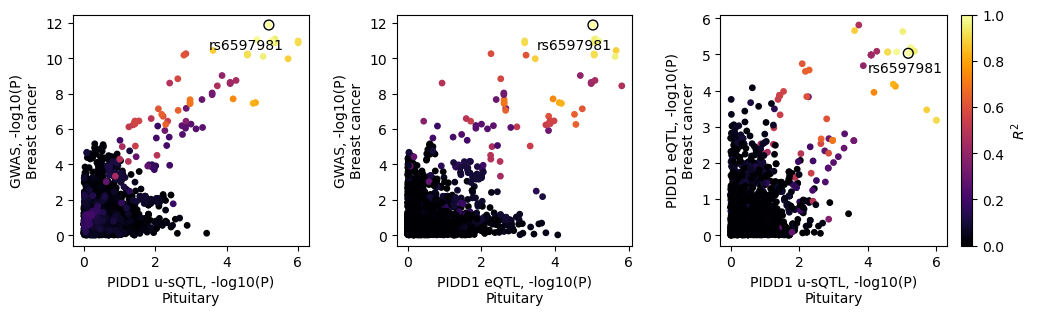

In [139]:
fig, ax = plt.subplots(ncols= 3, figsize=(12, 3), width_ratios=[1, 1, 1.2])
y = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float)))
x = -np.log10(np.array(nom.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr11:803017', snps_shared]

scatter_df = pd.DataFrame()
scatter_df['r2'] = r2
scatter_df['sQTL'] = x
scatter_df['GWAS'] = y
scatter_df = scatter_df.sort_values('r2')

c=ax[0].scatter(scatter_df.sQTL, scatter_df.GWAS, c=scatter_df.r2, s=15, cmap='inferno', vmin=0)
# plt.colorbar(c)
ax[0].set_xlabel('PIDD1 u-sQTL, -log10(P)\nPituitary')
ax[0].set_ylabel('GWAS, -log10(P)\nBreast cancer')

y_r = -np.log10(np.array(gwas_pval.loc[['chr11:803017']].P.astype(float)))
x_r = -np.log10(np.array(nom.loc[['chr11:803017']].nom_pval.astype(float)))
ax[0].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[0].text(3.5, 10.5, 'rs6597981')



y = -np.log10(np.array(gwas_pval.loc[snps_shared].P.astype(float)))
x = -np.log10(np.array(nom_e.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr11:803017', snps_shared]
c=ax[1].scatter(x, y, c=r2, s=15, cmap='inferno', vmin=0)
# plt.colorbar(c)
ax[1].set_xlabel('PIDD1 eQTL, -log10(P)\nPituitary')
ax[1].set_ylabel('GWAS, -log10(P)\nBreast cancer')

y_r = -np.log10(np.array(gwas_pval.loc[['chr11:803017']].P.astype(float)))
x_r = -np.log10(np.array(nom_e.loc[['chr11:803017']].nom_pval.astype(float)))
ax[1].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[1].text(3.5, 10.5, 'rs6597981')



x = -np.log10(np.array(nom.loc[snps_shared].nom_pval.astype(float)))
y = -np.log10(np.array(nom_e.loc[snps_shared].nom_pval.astype(float)))
r2 = LD.loc['chr11:803017', snps_shared]
c=ax[2].scatter(x, y, c=r2, s=15, cmap='inferno', vmin=0)
plt.colorbar(c, label=r'$R^2$')
ax[2].set_xlabel('PIDD1 u-sQTL, -log10(P)\nPituitary')
ax[2].set_ylabel('PIDD1 eQTL, -log10(P)\nBreast cancer')

x_r = -np.log10(np.array(nom.loc[['chr11:803017']].nom_pval.astype(float)))
y_r = -np.log10(np.array(nom_e.loc[['chr11:803017']].nom_pval.astype(float)))
ax[2].scatter(x_r, y_r, edgecolor='black',facecolor='none', s=50)
ax[2].text(4, 4.5, 'rs6597981')

fig.subplots_adjust(wspace=0.35, hspace=5)

In [140]:
qqnorm = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Pituitary/chr11.leafcutter.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 802376-30000, 802542+30000, file_type='leafcutter')

qqnorm_e = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Pituitary/chr11.expression.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 802376-30000, 802542+30000, file_type='expression')

qqnorm_bm = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Breast-MammaryTissue/chr11.leafcutter.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 802376-30000, 802542+30000, file_type='leafcutter')

qqnorm_bm_e = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Breast-MammaryTissue/chr11.expression.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 802376-30000, 802542+30000, file_type='expression')

qqnorm.index = qqnorm.pid
qqnorm_e.index = qqnorm_e.pid

qqnorm_bm.index = qqnorm_bm.pid
qqnorm_bm_e.index = qqnorm_bm_e.pid

In [143]:
nom.loc['chr11:803017'].slope

'-0.302786'

In [141]:
nom.loc['chr11:803017'].nom_pval

'6.48142e-06'

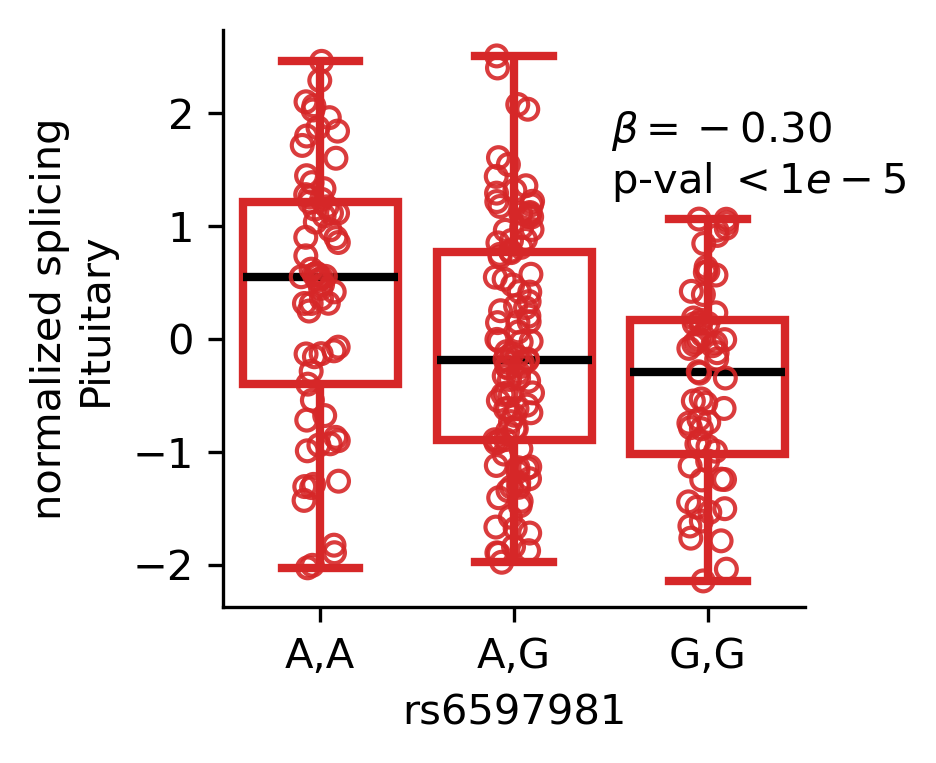

In [156]:
# records = get_best_snp_record(vcf_gtex, 'chr11:803017')
record = fetch_variant(vcf_in, 'chr11_803017_A_G_b38')


ax = make_boxplot_df(qqnorm, 'chr11:802376:802542:clu_21995_-:UP:chr11_803017_N_N_GCST004988', record, color = 'tab:red')
ax.set_xlabel('rs6597981')
ax.set_ylabel('normalized splicing\nPituitary')

ax.text(1.5, 1.3, r'$\beta = -0.30$' + '\np-val $< 1e-5$')


plt.savefig('../code/plots/fig4_PIDD1_boxplot_splicing.Pituitary.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4_PIDD1_boxplot_splicing.Pituitary.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4_PIDD1_boxplot_splicing.Pituitary.svg', dpi=300, bbox_inches='tight')

In [147]:
nom_e.loc['chr11:803017'].slope

'0.184477'

In [148]:
nom_e.loc['chr11:803017'].nom_pval

'9.28597e-06'

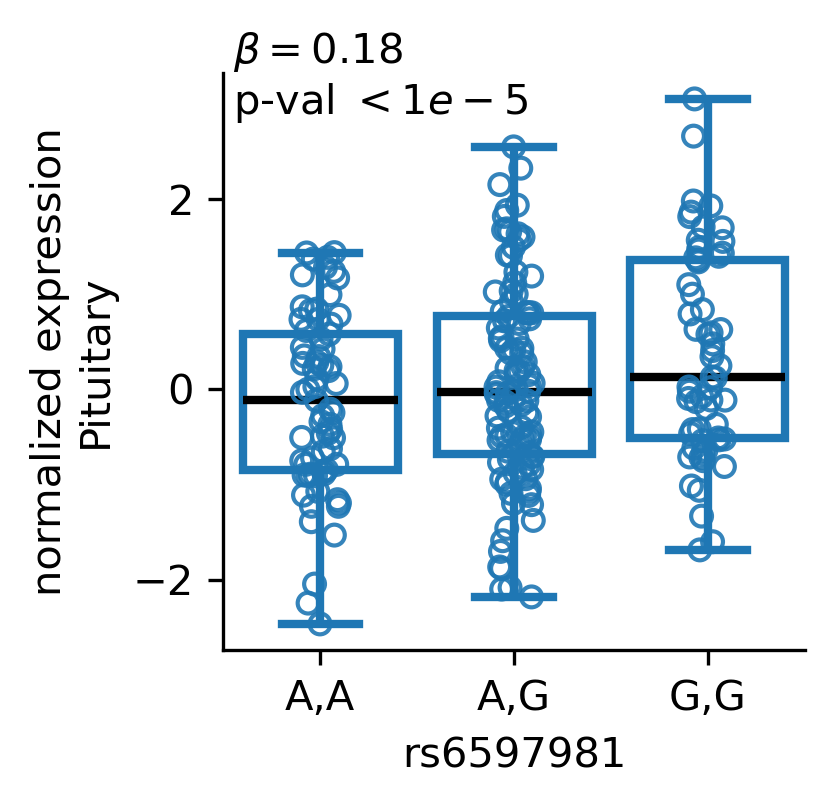

In [157]:
# ax = make_boxplot_df(qqnorm_bm_e, 'ENSG00000177595.18:chr11_803017_N_N_GCST004988', records[0])
# ax.set_xlabel('rs6597981')
# ax.set_ylabel('normalized expression\nBreast mammary tissue')


ax = make_boxplot_df(qqnorm_e, 'ENSG00000177595.18:chr11_803017_N_N_GCST004988', record, color = 'tab:blue')
ax.set_xlabel('rs6597981')
ax.set_ylabel('normalized expression\nPituitary')

ax.text(-0.45, 2.9, r'$\beta = 0.18$' + '\np-val $< 1e-5$')

plt.savefig('../code/plots/fig4_PIDD1_boxplot_expression.Pituitary.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4_PIDD1_boxplot_expression.Pituitary.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4_PIDD1_boxplot_expression.Pituitary.svg', dpi=300, bbox_inches='tight')

In [164]:
nom_bm = run_tabix('../code/results/coloc/qtls/Breast-MammaryTissue/leafcutter.NominalPass/chr11.txt.tabix.gz',
               'chr11', 0, 803017+1000000)

nom_bm['snp_pos'] = nom_bm.var_chr + ':' + nom_bm.var_from


nom_bm_e = run_tabix('../code/results/coloc/qtls/Breast-MammaryTissue/expression.NominalPass/chr11.txt.tabix.gz',
               'chr11', 0, 803017+1000000)

nom_bm_e['snp_pos'] = nom_bm_e.var_chr + ':' + nom_bm_e.var_from

nom_bm['gwas_trait'] = nom_bm['phe_id'].apply(lambda x: x.split(':')[-1])
nom_bm_e['gwas_trait'] = nom_bm_e['phe_id'].apply(lambda x: x.split(':')[-1])

# nom_bm = nom_bm.loc[(nom_bm.gwas_trait == 'chr11_803017_N_N_GCST004988') & (nom_bm['phe_id'] == 'chr11:802376:802542:clu_22443_-:UP:chr11_803017_N_N_GCST004988')]
# nom_bm_e = nom_bm_e.loc[(nom_bm_e.gwas_trait == 'chr11_803017_N_N_GCST004988') & (nom_bm_e['phe_id'].apply(lambda x: ('ENSG00000177595' in x) and ('chr11_803017_N_N_GCST004988' in x)))]



In [169]:
# nom_bm.loc[(nom_bm.gwas_trait == 'chr11_803017_N_N_GCST004988')].phe_id.unique()
# & (nom_bm['phe_id'] == 'chr11:802376:802542:clu_22443_-:UP:chr11_803017_N_N_GCST004988')

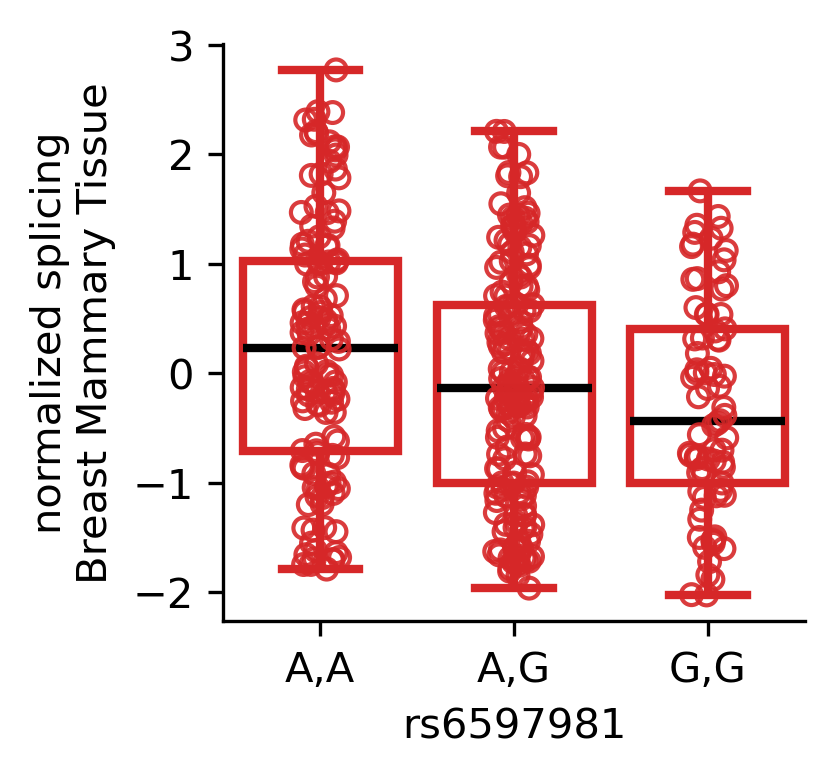

In [170]:
# records = get_best_snp_record(vcf_gtex, 'chr11:803017')
record = fetch_variant(vcf_in, 'chr11_803017_A_G_b38')


ax = make_boxplot_df(qqnorm_bm, 'chr11:802376:802542:clu_22443_-:UP:chr11_803017_N_N_GCST004988', record, color = 'tab:red')
ax.set_xlabel('rs6597981')
ax.set_ylabel('normalized splicing\nBreast Mammary Tissue')

# ax.text(1.5, 1.3, r'$\beta = -0.30$' + '\np-val $< 1e-5$')


plt.savefig('../code/plots/fig4_PIDD1_boxplot_splicing.Breast_Mammary_tissue.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4_PIDD1_boxplot_splicing.Breast_Mammary_tissue.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4_PIDD1_boxplot_splicing.Breast_Mammary_tissue.svg', dpi=300, bbox_inches='tight')

In [176]:
nom_bm_e.loc[(nom_bm_e.var_id == 'chr11_803017_A_G_b38') & (nom_bm_e.phe_id == 'ENSG00000177595.18:chr11_803017_N_N_GCST004988')].slope

203273    0.30204
Name: slope, dtype: object

In [177]:
nom_bm_e.loc[(nom_bm_e.var_id == 'chr11_803017_A_G_b38') & (nom_bm_e.phe_id == 'ENSG00000177595.18:chr11_803017_N_N_GCST004988')].nom_pval

203273    3.47565e-24
Name: nom_pval, dtype: object

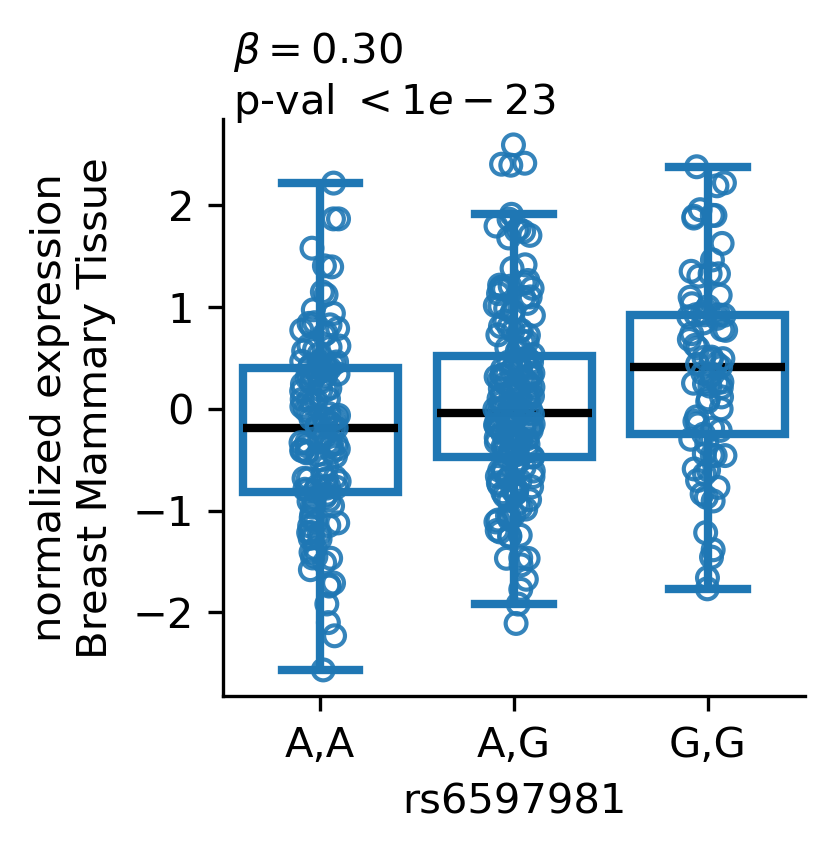

In [178]:
# ax = make_boxplot_df(qqnorm_bm_e, 'ENSG00000177595.18:chr11_803017_N_N_GCST004988', records[0])
# ax.set_xlabel('rs6597981')
# ax.set_ylabel('normalized expression\nBreast mammary tissue')


ax = make_boxplot_df(qqnorm_bm_e, 'ENSG00000177595.18:chr11_803017_N_N_GCST004988', record, color = 'tab:blue')
ax.set_xlabel('rs6597981')
ax.set_ylabel('normalized expression\nBreast Mammary Tissue')

ax.text(-0.45, 2.9, r'$\beta = 0.30$' + '\np-val $< 1e-23$')

plt.savefig('../code/plots/fig4_PIDD1_boxplot_expression.Breast_Mammary_tissue.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4_PIDD1_boxplot_expression.Breast_Mammary_tissue.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4_PIDD1_boxplot_expression.Breast_Mammary_tissue.svg', dpi=300, bbox_inches='tight')

In [180]:
annot = run_tabix('/project2/mstephens/cfbuenabadn/gtex-stm/code/Annotations/gencode.v44.primary_assembly.exons.bed.gz', 
          'chr11', 614037-30000, 614475+30000)

qqnorm = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Thyroid/chr11.leafcutter.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 614037-30000, 614475+30000, file_type='leafcutter')

qqnorm_e = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Thyroid/chr11.expression.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 614037-30000, 614475+30000, file_type='expression')

qqnorm_wb = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/WholeBlood/chr11.leafcutter.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 614037-30000, 614475+30000, file_type='leafcutter')

qqnorm_wb_e = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/WholeBlood/chr11.expression.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 614037-30000, 614475+30000, file_type='expression')


# qqnorm_lcl = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Cells-EBV-transformedlymphocytes/chr11.leafcutter.ForGWASColoc.sorted.qqnorm.bed.gz', 
#           'chr11', 614037-30000, 614475+30000, file_type='leafcutter')

# qqnorm_lcl_e = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Cells-EBV-transformedlymphocytes/chr11.expression.ForGWASColoc.sorted.qqnorm.bed.gz', 
#           'chr11', 614037-30000, 614475+30000, file_type='expression')


qqnorm_sp = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Spleen/chr11.leafcutter.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 614037-30000, 614475+30000, file_type='leafcutter')

qqnorm_sp_e = run_tabix('/project/yangili1/cfbuenabadn/leafcutter2_paper/code/results/coloc/data/Spleen/chr11.expression.ForGWASColoc.sorted.qqnorm.bed.gz', 
          'chr11', 614037-30000, 614475+30000, file_type='expression')

gwas = run_tabix('../code/resources/gwas/StatsForColoc/Hypothyroidism.standardized.txt.tabix.gz', 
          'chr11', 578759-500000, 578759+1000000)

gwas['snp_pos'] = gwas.chrom + ':' + gwas.start

gwas_pval = run_tabix('../code/resources/gwas/hg38_summary_stats/Hypothyroidism.bed.gz', 
          'chr11', 578759-500000, 578759+1000000)

gwas_pval['snp_pos'] = gwas_pval['chrom'] + ':' + gwas_pval.start

nom = run_tabix('../code/results/coloc/qtls/Thyroid/leafcutter.NominalPass/chr11.txt.tabix.gz',
               'chr11', 578759-500000, 578759+1000000)

nom['snp_pos'] = nom.var_chr + ':' + nom.var_from


nom_e = run_tabix('../code/results/coloc/qtls/Thyroid/expression.NominalPass/chr11.txt.tabix.gz',
               'chr11', 578759-500000, 578759+1000000)

nom_e['snp_pos'] = nom_e.var_chr + ':' + nom_e.var_from


nom['gwas_trait'] = nom['phe_id'].apply(lambda x: x.split(':')[-1])
nom_e['gwas_trait'] = nom_e['phe_id'].apply(lambda x: x.split(':')[-1])





nom_wb = run_tabix('../code/results/coloc/qtls/WholeBlood/leafcutter.NominalPass/chr11.txt.tabix.gz',
               'chr11', 578759-500000, 578759+1000000)

nom_wb['snp_pos'] = nom_wb.var_chr + ':' + nom_wb.var_from


nom_wb_e = run_tabix('../code/results/coloc/qtls/WholeBlood/expression.NominalPass/chr11.txt.tabix.gz',
               'chr11', 578759-500000, 578759+1000000)

nom_wb_e['snp_pos'] = nom_wb_e.var_chr + ':' + nom_wb_e.var_from

nom_wb['gwas_trait'] = nom_wb['phe_id'].apply(lambda x: x.split(':')[-1])
nom_wb_e['gwas_trait'] = nom_wb_e['phe_id'].apply(lambda x: x.split(':')[-1])





nom_sp = run_tabix('../code/results/coloc/qtls/Spleen/leafcutter.NominalPass/chr11.txt.tabix.gz',
               'chr11', 578759-500000, 578759+1000000)

nom_sp['snp_pos'] = nom_sp.var_chr + ':' + nom_sp.var_from


nom_sp_e = run_tabix('../code/results/coloc/qtls/Spleen/expression.NominalPass/chr11.txt.tabix.gz',
               'chr11', 578759-500000, 578759+1000000)

nom_sp_e['snp_pos'] = nom_sp_e.var_chr + ':' + nom_sp_e.var_from

nom_sp['gwas_trait'] = nom_sp['phe_id'].apply(lambda x: x.split(':')[-1])
nom_sp_e['gwas_trait'] = nom_sp_e['phe_id'].apply(lambda x: x.split(':')[-1])





nom = nom.loc[(nom.gwas_trait == 'chr11_578759_N_N_Hypothyroidism') & (nom['phe_id'] == 'chr11:614037:614475:clu_22612_-:UP:chr11_578759_N_N_Hypothyroidism')]
nom_e = nom_e.loc[(nom_e.gwas_trait == 'chr11_578759_N_N_Hypothyroidism') & (nom_e['phe_id'].apply(lambda x: ('ENSG00000185507' in x) and ('chr11_578759_N_N_Hypothyroidism' in x)))]

nom_wb = nom_wb.loc[(nom_wb.gwas_trait == 'chr11_578759_N_N_Hypothyroidism') & (nom_wb['phe_id'] == 'chr11:614037:614475:clu_19954_-:UP:chr11_578759_N_N_Hypothyroidism')]
nom_wb_e = nom_wb_e.loc[(nom_wb_e.gwas_trait == 'chr11_578759_N_N_Hypothyroidism') & (nom_wb_e['phe_id'].apply(lambda x: ('ENSG00000185507' in x) and ('chr11_578759_N_N_Hypothyroidism' in x)))]

# nom_lcl = nom_lcl.loc[(nom_lcl.gwas_trait == 'chr11_578759_N_N_Hypothyroidism') & (nom_lcl['#phe_id'] == 'chr11:614037:614475:clu_18165_-:UP:chr11_578759_N_N_Hypothyroidism')]
# nom_lcl_e = nom_lcl_e.loc[(nom_lcl_e.gwas_trait == 'chr11_578759_N_N_Hypothyroidism') & (nom_lcl_e['#phe_id'].apply(lambda x: ('ENSG00000185507' in x) and ('chr11_578759_N_N_Hypothyroidism' in x)))]

nom_sp = nom_sp.loc[(nom_sp.gwas_trait == 'chr11_578759_N_N_Hypothyroidism') & (nom_sp['phe_id'] == 'chr11:614037:614475:clu_20133_-:UP:chr11_578759_N_N_Hypothyroidism')]
nom_sp_e = nom_sp_e.loc[(nom_sp_e.gwas_trait == 'chr11_578759_N_N_Hypothyroidism') & (nom_sp_e['phe_id'].apply(lambda x: ('ENSG00000185507' in x) and ('chr11_578759_N_N_Hypothyroidism' in x)))]






In [181]:
# rs7941547

qqnorm.index = qqnorm.pid
qqnorm_e.index = qqnorm_e.pid

qqnorm_wb.index = qqnorm_wb.pid

qqnorm_wb_e.index = qqnorm_wb_e.pid

qqnorm_sp.index = qqnorm_sp.pid
qqnorm_sp_e.index = qqnorm_sp_e.pid

In [184]:
nom.loc[(nom.var_id == 'chr11_611503_G_A_b38') & (nom.phe_id == 'chr11:614037:614475:clu_22612_-:UP:chr11_578759_N_N_Hypothyroidism')].slope

453547    -0.316855
Name: slope, dtype: object

In [183]:
nom.loc[(nom.var_id == 'chr11_611503_G_A_b38') & (nom.phe_id == 'chr11:614037:614475:clu_22612_-:UP:chr11_578759_N_N_Hypothyroidism')].nom_pval

453547    8.33325e-18
Name: nom_pval, dtype: object

In [ ]:
nom_bm_e.loc[(nom_bm_e.var_id == 'chr11_803017_A_G_b38') & (nom_bm_e.phe_id == 'ENSG00000177595.18:chr11_803017_N_N_GCST004988')].nom_pval

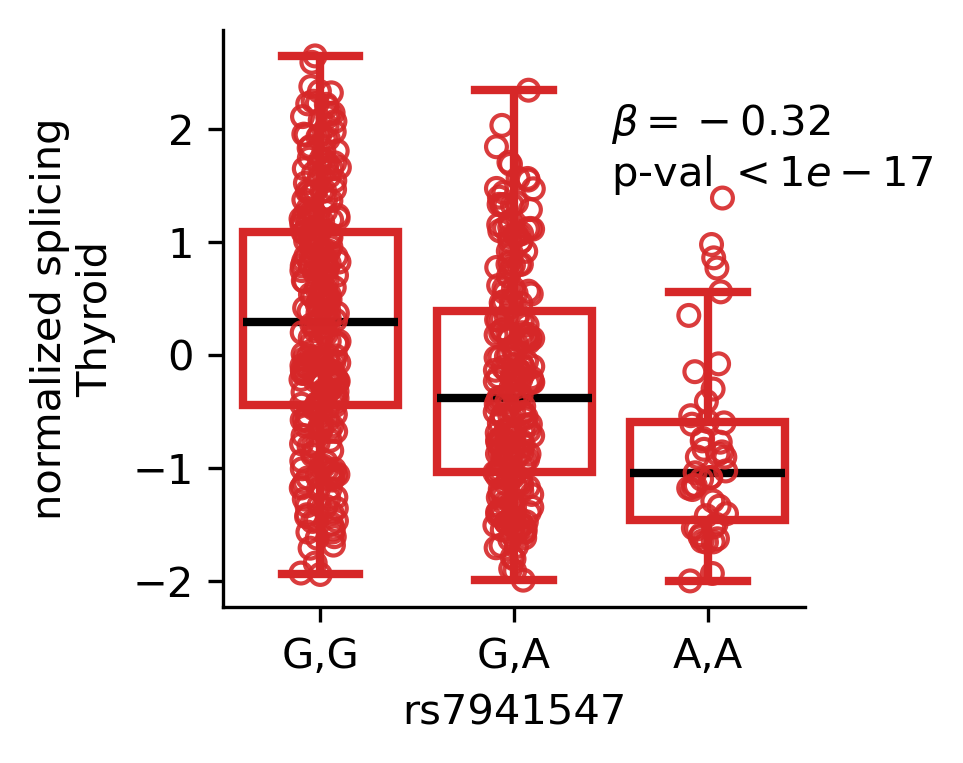

In [186]:
record = fetch_variant(vcf_in, 'chr11_611503_G_A_b38')

ax = make_boxplot_df(qqnorm, 'chr11:614037:614475:clu_22612_-:UP:chr11_578759_N_N_Hypothyroidism', record, color='tab:red')
ax.set_xlabel('rs7941547')
ax.set_ylabel('normalized splicing\nThyroid')

ax.text(1.5, 1.5, r'$\beta = -0.32$' + '\np-val $< 1e-17$')


plt.savefig('../code/plots/fig4_IRF7_boxplot_splicing.Thyroid.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4_IRF7_boxplot_splicing.Thyroid.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4_IRF7_boxplot_splicing.Thyroid.svg', dpi=300, bbox_inches='tight')

In [188]:
nom_e.loc[(nom_e.var_id == 'chr11_611503_G_A_b38') & (nom_e.phe_id == 'ENSG00000185507.21:chr11_578759_N_N_Hypothyroidism')].slope

148079    0.236438
Name: slope, dtype: object

In [189]:
nom_e.loc[(nom_e.var_id == 'chr11_611503_G_A_b38') & (nom_e.phe_id == 'ENSG00000185507.21:chr11_578759_N_N_Hypothyroidism')].nom_pval

148079    1.51762e-12
Name: nom_pval, dtype: object

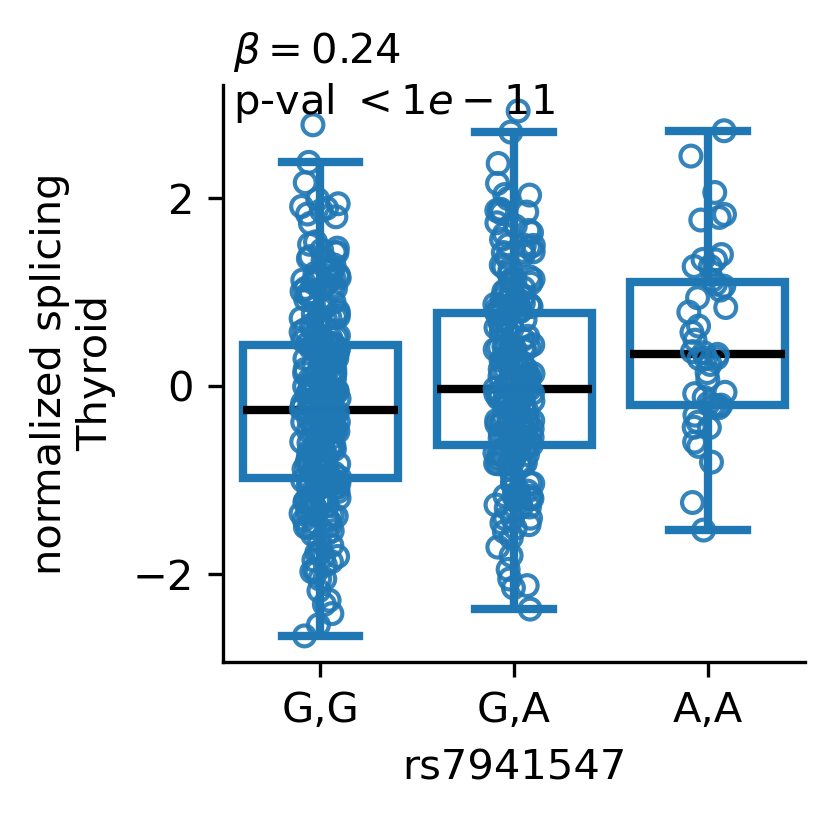

In [190]:
# records = get_best_snp_record(vcf_gtex, 'chr11:611503')

ax = make_boxplot_df(qqnorm_e, 'ENSG00000185507.21:chr11_578759_N_N_Hypothyroidism', record, color='tab:blue')
ax.set_xlabel('rs7941547')
ax.set_ylabel('normalized splicing\nThyroid')

ax.text(-0.45, 2.9, r'$\beta = 0.24$' + '\np-val $< 1e-11$')


plt.savefig('../code/plots/fig4_IRF7_boxplot_expression.Thyroid.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4_IRF7_boxplot_expression.Thyroid.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4_IRF7_boxplot_expression.Thyroid.svg', dpi=300, bbox_inches='tight')

In [ ]:
nom

In [191]:
nom_wb.loc[(nom_wb.var_id == 'chr11_611503_G_A_b38') & (nom_wb.phe_id == 'chr11:614037:614475:clu_19954_-:UP:chr11_578759_N_N_Hypothyroidism')].slope

294046    -0.307007
Name: slope, dtype: object

In [192]:
nom_wb.loc[(nom_wb.var_id == 'chr11_611503_G_A_b38') & (nom_wb.phe_id == 'chr11:614037:614475:clu_19954_-:UP:chr11_578759_N_N_Hypothyroidism')].nom_pval

294046    3.01531e-23
Name: nom_pval, dtype: object

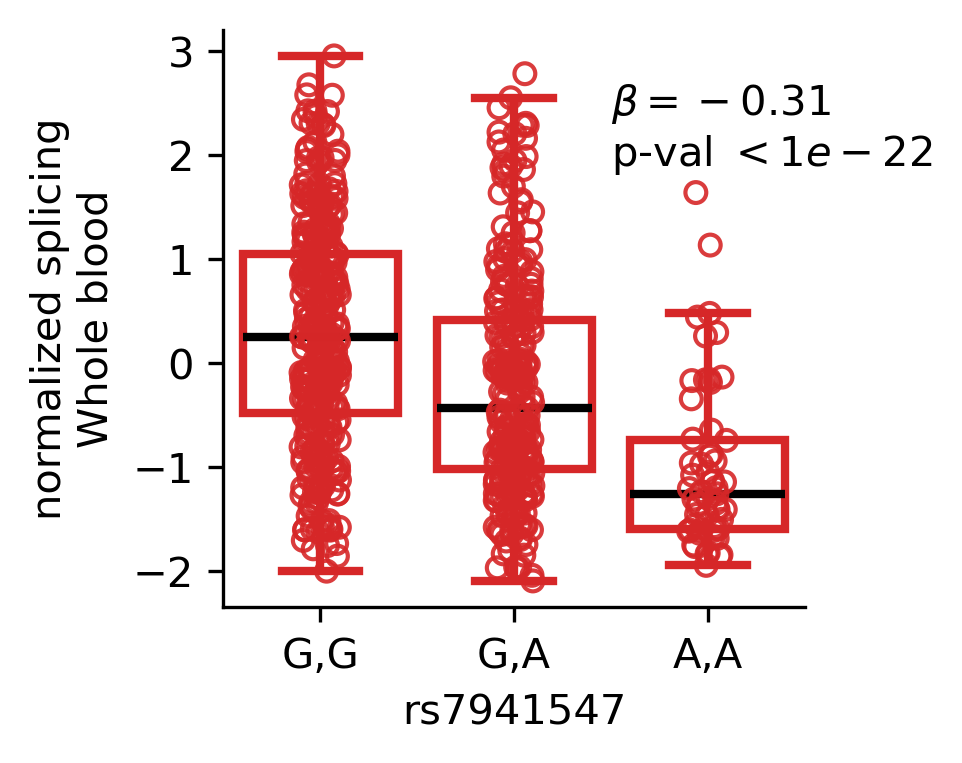

In [198]:
ax = make_boxplot_df(qqnorm_wb, 'chr11:614037:614475:clu_19954_-:UP:chr11_578759_N_N_Hypothyroidism', record, color='tab:red')
ax.set_xlabel('rs7941547')
ax.text(1.5, 1.9, r'$\beta = -0.31$' + '\np-val $< 1e-22$')

ax.set_ylabel('normalized splicing\nWhole blood')

plt.savefig('../code/plots/fig4_IRF7_boxplot_splicing.WholeBlood.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4_IRF7_boxplot_splicing.WholeBlood.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4_IRF7_boxplot_splicing.WholeBlood.svg', dpi=300, bbox_inches='tight')

In [194]:
nom_sp.loc[(nom_sp.var_id == 'chr11_611503_G_A_b38') & (nom_sp.phe_id == 'chr11:614037:614475:clu_20133_-:UP:chr11_578759_N_N_Hypothyroidism')].slope

167073    -0.324012
Name: slope, dtype: object

In [195]:
nom_sp.loc[(nom_sp.var_id == 'chr11_611503_G_A_b38') & (nom_sp.phe_id == 'chr11:614037:614475:clu_20133_-:UP:chr11_578759_N_N_Hypothyroidism')].nom_pval

167073    4.53821e-09
Name: nom_pval, dtype: object

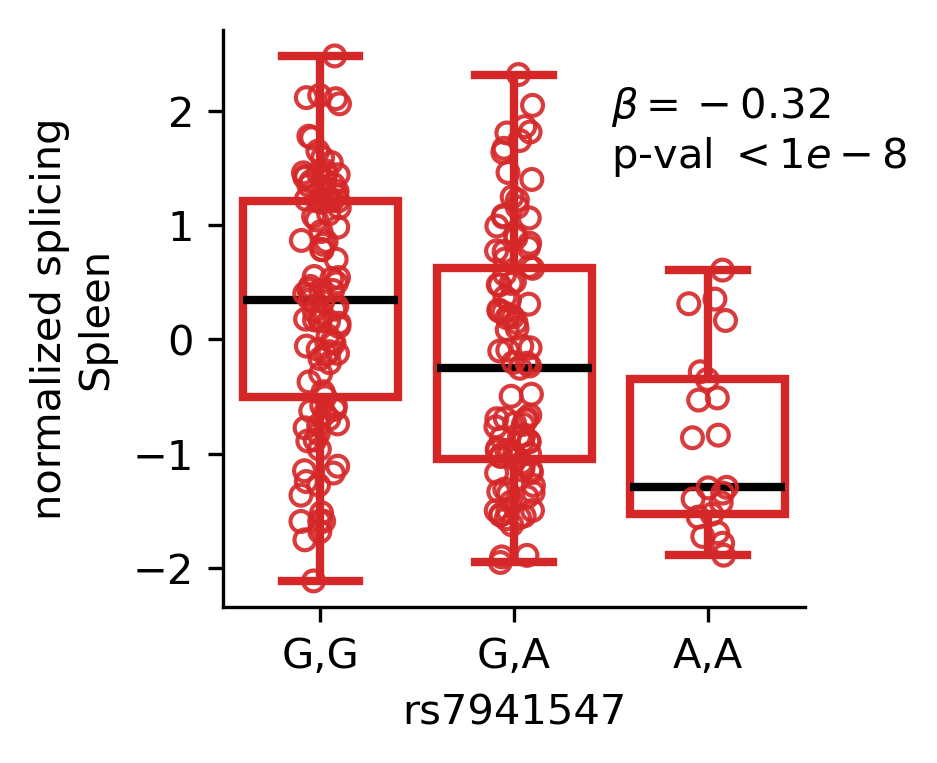

In [200]:
ax = make_boxplot_df(qqnorm_sp, 'chr11:614037:614475:clu_20133_-:UP:chr11_578759_N_N_Hypothyroidism', record, color='tab:red')
ax.set_xlabel('rs7941547')
ax.text(1.5, 1.5, r'$\beta = -0.32$' + '\np-val $< 1e-8$')

ax.set_ylabel('normalized splicing\nSpleen')

plt.savefig('../code/plots/fig4_IRF7_boxplot_splicing.Spleen.png', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4_IRF7_boxplot_splicing.Spleen.pdf', dpi=300, bbox_inches='tight')
plt.savefig('../code/plots/fig4_IRF7_boxplot_splicing.Spleen.svg', dpi=300, bbox_inches='tight')